<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 6</h3>
    <h3>Ejercicio A - Prophet & Neural Prophet</h3>
        <p>Docente: Rodrigo Del Rosso, Braian Drago, Sebastian Calcagno <p>
</div>

# **Clase 6: Redes Neuronales en Series Temporales**

Prophet  o Facebook Prophet (2017) es el predecesor de NeuralProphet (2020)

En resumen...  
**Prophet:**  
Modelo de series temporales desarrollado por Facebook. Se basa en descomposición aditiva (tendencia + estacionalidad + vacaciones/ días festivos) y permite capturar estacionalidades múltiples de forma automática. Es robusto ante datos faltantes y cambios abruptos.
  
**NeuralProphet:**  
Extiende Prophet combinándolo con redes neuronales (basado en PyTorch). Integra capacidades de aprendizaje profundo como auto-regresión, múltiples estacionalidades, eventos, covariables y predicción multivariada. Captura patrones no lineales más complejos que Prophet.

*Algunos artículos de interes:*

**Is NeuralProphet better than Prophet for sales forecasting?:** https://blog.ml6.eu/is-neuralprophet-better-than-prophet-for-sales-forecasting-de45527163dc  

**Neural Prophet vs. Prophet:** https://dataamber.medium.com/neural-prophet-vs-prophet-why-neural-prophet-is-so-accurate-60fe1313ac05#:~:text=Compared%20with%20the%20traditional%20AR,willing%20to%20use%20it%20everywhere.

In [ ]:
# Se cargan las librerías
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from pandas import DataFrame
from pandas import concat
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import gc
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
%matplotlib inline

# **Ejemplo Dataset Air Passengers**

Este conjunto de datos proporciona totales mensuales de pasajeros de una aerolínea estadounidense desde 1949 hasta 1960.

**STATSFORECAST!! <-----** (Lightning fast forecasting with statistical and econometric models)

In [ ]:
!pip install statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.0/501.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.3 MB/s eta 0:00:00


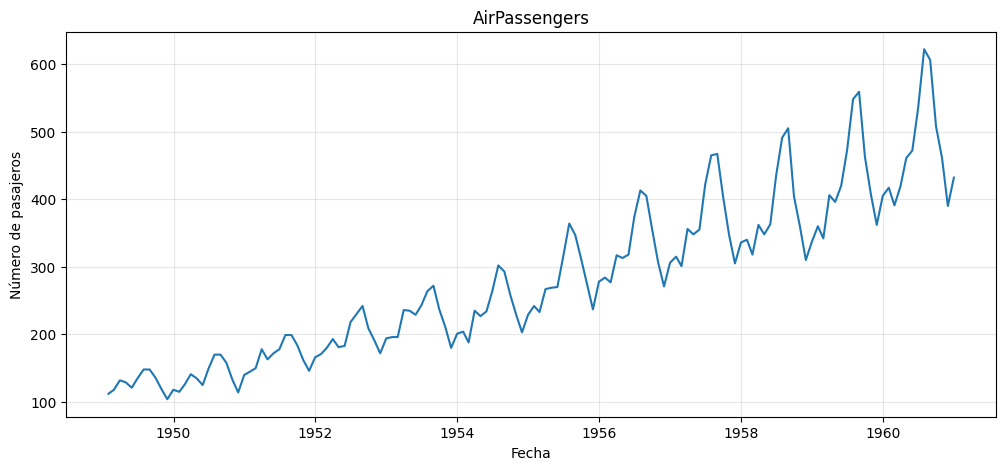

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.utils import AirPassengersDF
import matplotlib.pyplot as plt

df2 = AirPassengersDF

plt.figure(figsize=(12, 5))

plt.plot(df2["ds"], df2["y"])

plt.title("AirPassengers")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
train2 = df2[:int(0.7*(len(df2)))]
test2 = df2[int(0.7*(len(df2))):]

In [ ]:
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='MS',
)
sf.fit(train2)

StatsForecast(models=[AutoARIMA])

In [ ]:
forecast2 = sf.predict(h=44, level=[95])

In [ ]:
forecast2.head(10)

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95
0,1.0,1957-05-01,353.563518,334.834576,372.292461
1,1.0,1957-06-01,406.741395,383.571824,429.910966
2,1.0,1957-07-01,448.056405,420.442731,475.670078
3,1.0,1957-08-01,438.040002,406.782125,469.297880
4,1.0,1957-09-01,391.360191,356.797272,425.923110
5,1.0,1957-10-01,344.787072,307.219552,382.354591
6,1.0,1957-11-01,309.346013,268.994265,349.697762
7,1.0,1957-12-01,345.670777,302.715586,388.625967
8,1.0,1958-01-01,354.008359,308.598563,399.418154
9,1.0,1958-02-01,341.554089,293.815779,389.292398


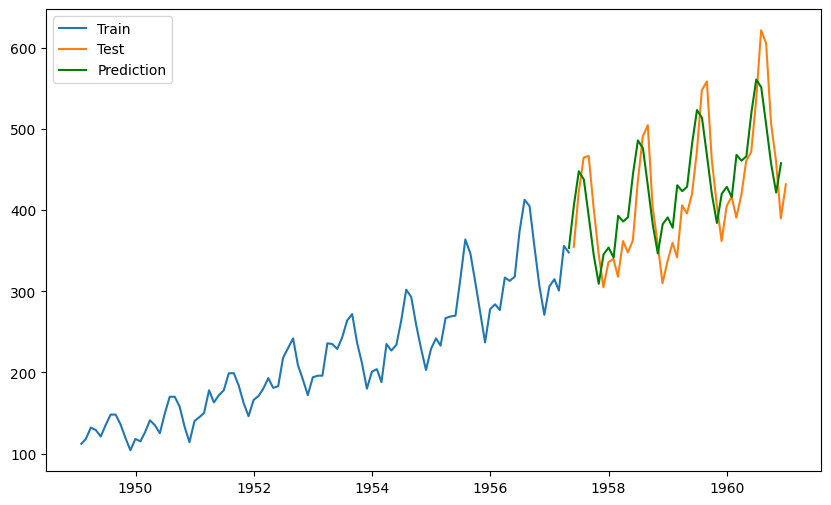

In [ ]:
# Adaptar columnas
forecast2 = forecast2.rename(columns={"AutoARIMA": "yhat",
                                      "AutoARIMA-lo-95": "yhat_lo",
                                      "AutoARIMA-hi-95": "yhat_hi"})

# Graficar
plt.figure(figsize=(10,6))
plt.plot(train2['ds'], train2['y'], label='Train')
plt.plot(test2['ds'], test2['y'], label='Test')
plt.plot(forecast2['ds'], forecast2['yhat'], label='Prediction', color="green")

# Opcional: agregar intervalos de confianza
#plt.fill_between(forecast2['ds'],
#                 forecast2['yhat_lo'],
#                 forecast2['yhat_hi'])

plt.legend()
plt.show()

## **Prophet o Facebook Prophet**  
https://facebook.github.io/prophet/docs/quick_start.html#python-api

[Página Oficial](https://facebook.github.io/prophet/) [Fuente del Ejemplo](https://www.kaggle.com/prashant111/tutorial-time-series-forecasting-with-prophet?scriptVersionId=50165664)  

https://facebook.github.io/prophet/docs/installation.html#python

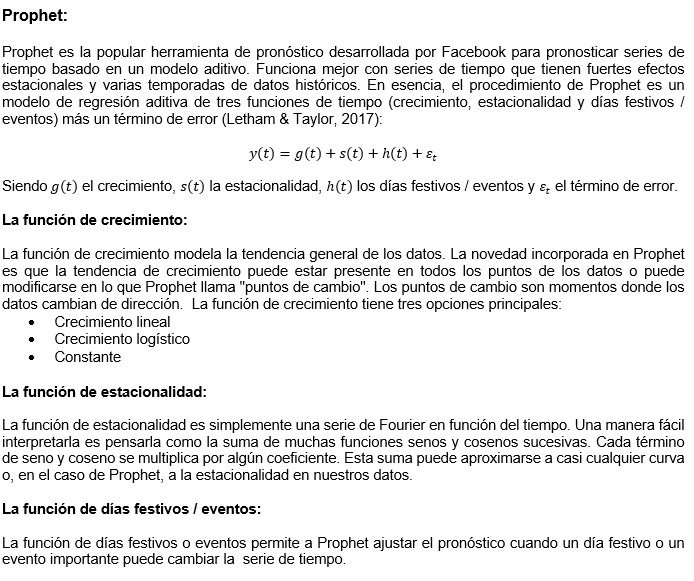

In [ ]:
# Se carga la base
url='https://raw.githubusercontent.com/braiandrago/AST/main/AirPassengers.csv'
df = pd.read_csv(url)
df['Month'] = pd.to_datetime(df['Month'])
df.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


La entrada a Prophet es siempre un dataframe con dos columnas: **ds** e **y**.

La columna **ds** (date stamp) debe tener el formato usado por Pandas, idealmente AAAA-MM-DD para una fecha o AAAA-MM-DD HH: MM: SS para tiempo.

La columna **y** debe ser numérica y representa la medida que deseamos pronosticar.

In [ ]:
# Se redefinen las variables para poder aplicar la librería Prophet
df = df.rename({'Month':'ds','#Passengers':'y'}, axis='columns')
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [ ]:
# Se define la base de entrenamiento (70%) y testeo (30%)
train = df[:int(0.7*(len(df)))]
test = df[int(0.7*(len(df))):]
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 100 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      44 non-null     datetime64[ns]
 1   y       44 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 836.0 bytes


In [ ]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

## Incertidumbre en la tendencia con Prophet

La mayor fuente de incertidumbre en las predicciones de Prophet no proviene de la estacionalidad o el error aleatorio, sino de los cambios potenciales en la tendencia futura.

Como no sabemos a ciencia cierta cómo cambiará la tendencia más adelante, Prophet hace una suposición razonable:

**“La frecuencia y magnitud de los cambios en la tendencia en el futuro serán similares a los del pasado”.**

**¿Cómo lo hace?**  
Durante el ajuste, Prophet identifica changepoints (puntos donde la tendencia cambia).

A partir de eso, genera una distribución de posibles futuros cambios de tendencia.

Esa distribución se usa para calcular intervalos de incertidumbre (confidence intervals) en las predicciones.

*changepoint_prior_scale:* regula cuán flexible puede ser la tendencia

In [ ]:
# Se inicializa y entrena el modelo
# Se define el intervalo de confianza en 95% (el valor por default es 80%)
m = Prophet(interval_width=0.95)
m.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Se define la cantidad de períodos a predecir. 44 equivale a la base de testeo
future = m.make_future_dataframe(periods=44, freq='MS')

En el parámetro freq se define la frecuencia mensual (MS) para las predicciones

In [ ]:
# Se generan las predicciones
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
139,1960-08-01,522.032391,494.812624,550.317321
140,1960-09-01,490.316988,463.123192,516.677686
141,1960-10-01,463.482833,435.467078,491.660574
142,1960-11-01,440.146160,410.181763,468.541004
143,1960-12-01,465.638337,436.739606,492.869279


*   yhat: es la predicción
*   yhat_lower: es el límite inferior de la predicción
*   yhat_upper: es el límite superior de la predicción

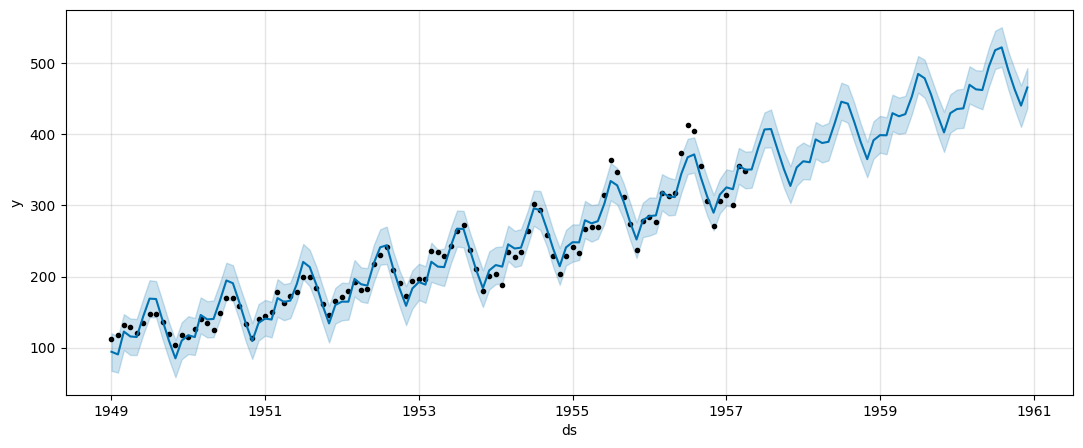

In [ ]:
# Se grafican las predicciones (línea) y la base de entranamiento (puntos)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(13)
fig = m.plot(forecast,ax=ax)
plt.show()

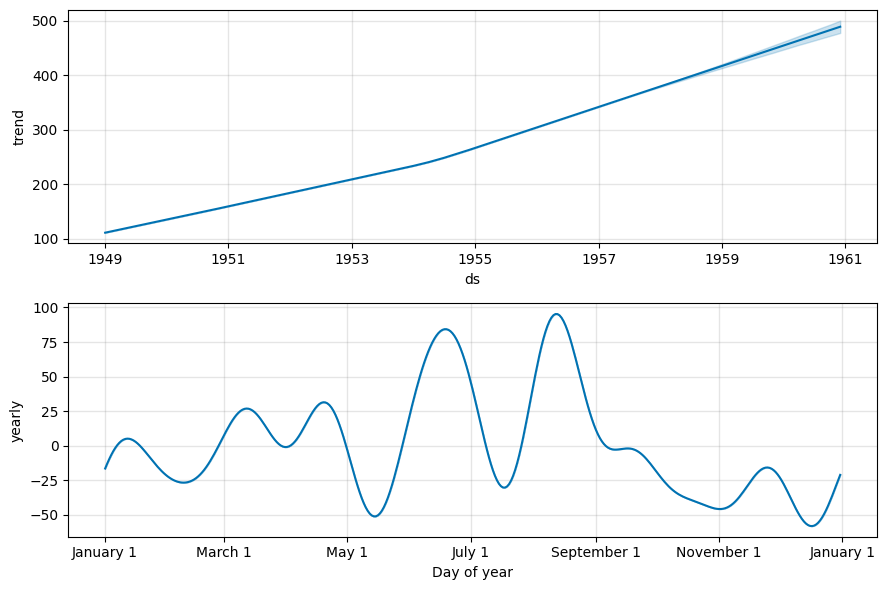

In [ ]:
# Se grafican las componenestes de las predicciones
fig2 = m.plot_components(forecast)

Estos gráficos muestran que la tendencia de pasajeros es creciente con los años y que los meses de más tráfico son los de las vacaciones de Julio y Agosto

In [ ]:
# Configuración para obtener gráficos interactivos
from plotly.offline import iplot, init_notebook_mode
import plotly.graph_objs as go

In [ ]:
def configure_plotly_browser_state():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              plotly: 'https://cdn.plot.ly/plotly-latest.min.js?noext',
            },
          });
        </script>
        '''))

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

In [ ]:
#import plotly.express as px
configure_plotly_browser_state()
init_notebook_mode(connected=False)
fig = plot_plotly(m, forecast) # Replace with your own data
fig.show()

Este resultado de la celda es demasiado extenso, por lo que solo se puede mostrar si accedes.


In [ ]:
# Se grafican las componentes de las predicciones
configure_plotly_browser_state()
init_notebook_mode(connected=False)
fig = plot_components_plotly(m, forecast)
fig.show()


Este resultado de la celda es demasiado extenso, por lo que solo se puede mostrar si accedes.


Los puntos de cambio son aquellos momentos donde la serie tiene un cambio abrupto en su trayectoria. Por default Prophet agrega 25 puntos de cambio al 80% del conjunto de datos.

Los puntos de cambio son los lugares donde el modelo detecta que hay un cambio en la tendencia de la serie temporal.

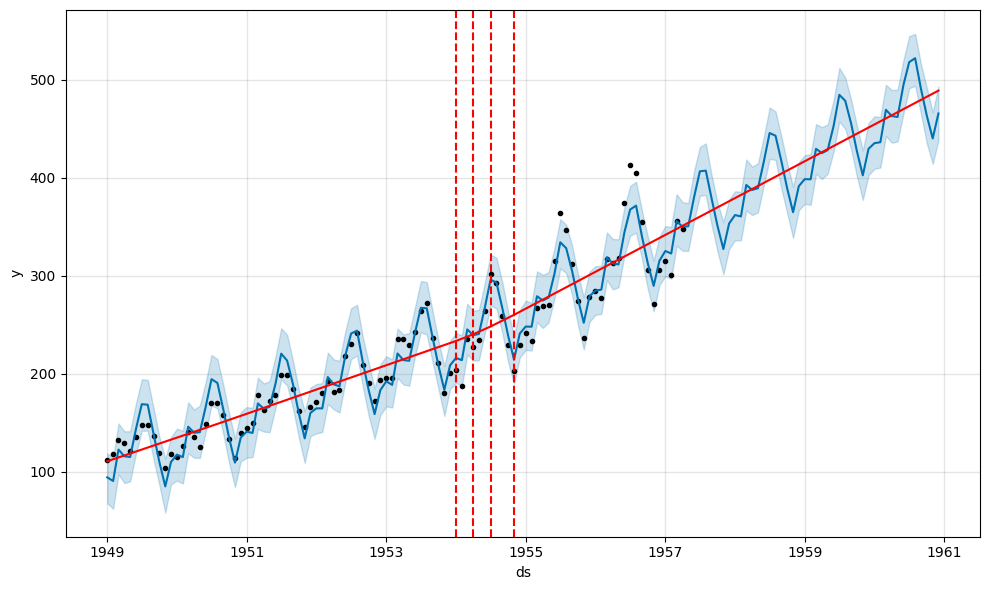

In [ ]:
# Se grafican los puntos de cambio
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [ ]:
m.changepoints

,ds
3,1949-04-01
6,1949-07-01
9,1949-10-01
13,1950-02-01
16,1950-05-01
19,1950-08-01
22,1950-11-01
25,1951-02-01
28,1951-05-01
32,1951-09-01


m = Prophet(n_changepoints=10)  # solo 10 posibles puntos

m = Prophet(changepoints=['1953-01-01', '1955-01-01'])

pocos candidatos, rigidez alta: m1 = Prophet(n_changepoints=5, changepoint_prior_scale=0.01)

Modificación de *Changepoints* -----> Riesgo: puede sobreajustar (seguir demasiado al ruido).

In [ ]:
# Hacer el modelo más flexible (más changepoints) - 	Flexibilidad del modelo para cambiar la tendencia (cantidad y magnitud de changepoints)
# m = Prophet(changepoint_prior_scale=0.2)
# m.fit(train)

# Hacer el modelo más rígido (menos changepoints)
# m = Prophet(changepoint_prior_scale=0.01)
# m.fit(train)

In [ ]:
# Se generan las predicciones para la base de testeo
X_tst_forecast = m.predict(test)
X_tst_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
39,1960-08-01,522.032391,497.919050,548.995561
40,1960-09-01,490.316988,463.723188,516.285273
41,1960-10-01,463.482833,436.973266,489.625310
42,1960-11-01,440.146160,410.352040,466.774695
43,1960-12-01,465.638337,437.169672,493.062929


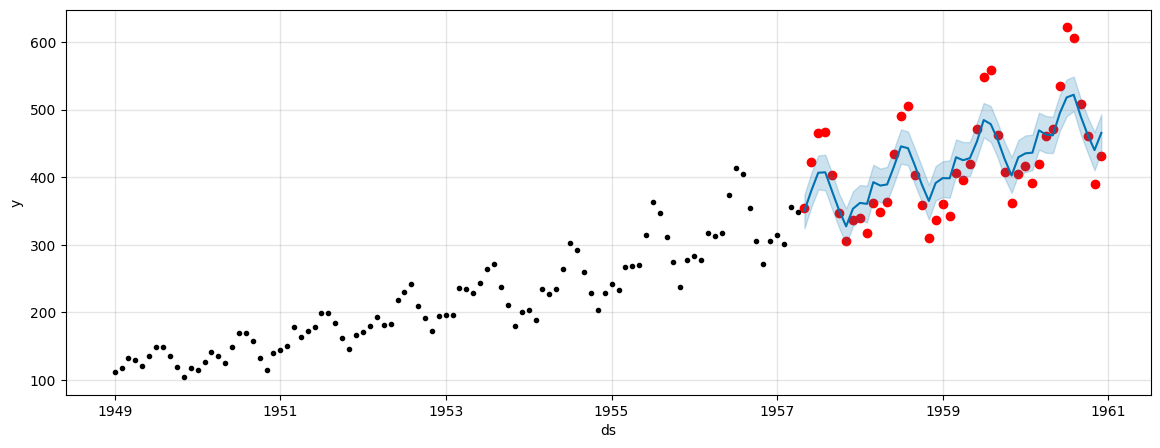

In [ ]:
# Se grafican la base de entrenamiento (punteado negro), la de testeo (punteado rojo) y las predicciones (azul)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(14)
ax.scatter(test.ds, test['y'], color='r')
fig = m.plot(X_tst_forecast, ax=ax)

In [ ]:
# Cálculo de las medidas de precisión
rmse = sqrt(mean_squared_error(test['y'], X_tst_forecast['yhat']))
print('Test RMSE: %.3f' % rmse)
mse = mean_squared_error(test['y'], X_tst_forecast['yhat'])
print('Test MSE: %.3f' % mse)
mae = mean_absolute_error(test['y'], X_tst_forecast['yhat'])
print('Test MAE: %.3f' % mae)
r2 = r2_score(test['y'], X_tst_forecast['yhat'])
print('Test R2: %.3f' % r2)

Test RMSE: 41.872
Test MSE: 1753.306
Test MAE: 35.060
Test R2: 0.700


In [ ]:
m = Prophet(interval_width=0.95, yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train)

In [ ]:
print(m.seasonalities)

OrderedDict({'yearly': {'period': 365.25, 'fourier_order': 10, 'prior_scale': 10.0, 'mode': 'additive', 'condition_name': None}})


In [ ]:
# Habilitar la estacionalidad semanal, diaria y anual
m = Prophet(interval_width=0.95, yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(train)

In [ ]:
print(m.seasonalities)

OrderedDict({'yearly': {'period': 365.25, 'fourier_order': 10, 'prior_scale': 10.0, 'mode': 'additive', 'condition_name': None}, 'weekly': {'period': 7, 'fourier_order': 3, 'prior_scale': 10.0, 'mode': 'additive', 'condition_name': None}})


In [ ]:
# Se define la cantidad de períodos a predecir. 44 equivale a la base de testeo
future = m.make_future_dataframe(periods=44, freq='MS')

In [ ]:
# Se generan las predicciones
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
139,1960-08-01,517.775698,491.943060,545.702595
140,1960-09-01,492.661411,468.262877,519.894625
141,1960-10-01,464.785222,435.466278,491.536039
142,1960-11-01,438.843257,413.485416,467.278159
143,1960-12-01,468.074079,440.990395,495.144606


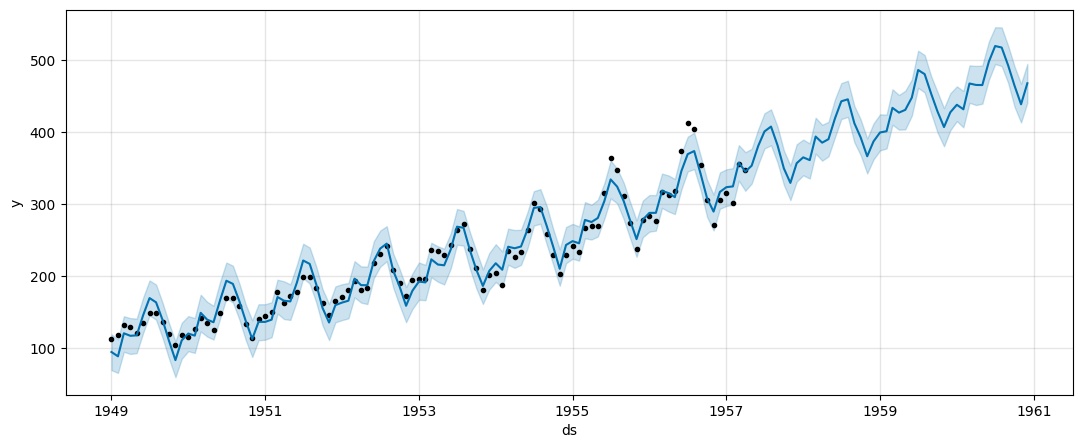

In [ ]:
# Se grafican las predicciones (línea) y la base de entranamiento (puntos)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(13)
fig = m.plot(forecast,ax=ax)
plt.show()

In [ ]:
# Se generan las predicciones para la base de testeo
X_tst_forecast = m.predict(test)
X_tst_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
39,1960-08-01,517.775698,489.935154,543.516330
40,1960-09-01,492.661411,466.534066,520.029670
41,1960-10-01,464.785222,438.749200,492.087755
42,1960-11-01,438.843257,412.175825,464.826114
43,1960-12-01,468.074079,442.163623,497.223522


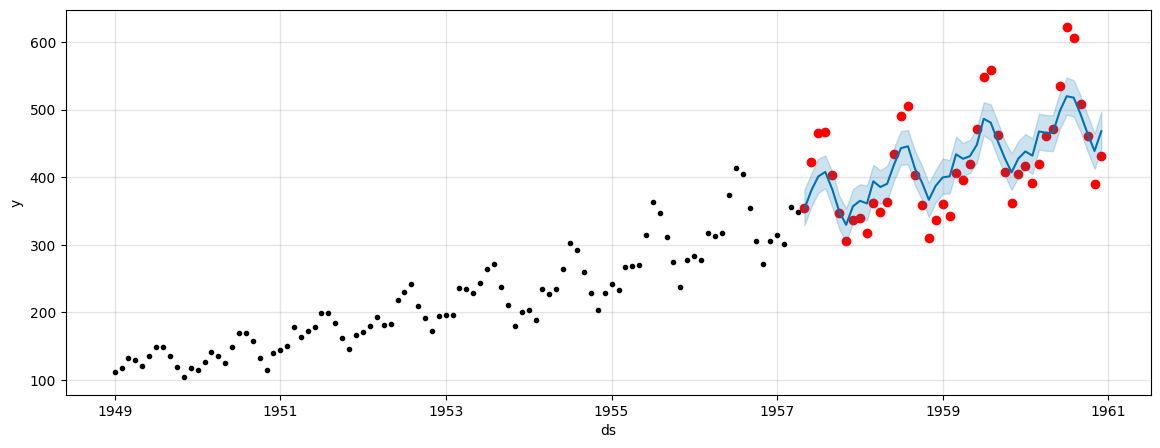

In [ ]:
# Se grafican la base de entrenamiento (punteado negro), la de testeo (punteado rojo) y las predicciones (azul)
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(14)
ax.scatter(test.ds, test['y'], color='r')
fig = m.plot(X_tst_forecast, ax=ax)

In [ ]:
# Cálculo de las medidas de precisión
rmse = sqrt(mean_squared_error(test['y'], X_tst_forecast['yhat']))
print('Test RMSE: %.3f' % rmse)
mse = mean_squared_error(test['y'], X_tst_forecast['yhat'])
print('Test MSE: %.3f' % mse)
mae = mean_absolute_error(test['y'], X_tst_forecast['yhat'])
print('Test MAE: %.3f' % mae)
r2 = r2_score(test['y'], X_tst_forecast['yhat'])
print('Test R2: %.3f' % r2)

Test RMSE: 42.140
Test MSE: 1775.750
Test MAE: 35.425
Test R2: 0.696


Otros adicionales....

**Holidays (por ejemplo por intervenciones de mantenimiento)**

Si esas fechas siempre tienen una caída (ej. por mantenimiento o paro) → Prophet va a asignar un valor negativo al efecto holiday.

In [ ]:
# Python
dias_feriados = pd.DataFrame({
  'holiday': 'Mantenimiento',
  'ds': pd.to_datetime(['1949-09-01', '1950-09-01', '1951-08-01','1951-09-01',
                        '1952-09-01', '1953-09-01', '1954-09-01', '1955-09-01', '1956-08-01','1956-09-01',
                        '1957-09-01', '1958-09-01', '1959-09-01', '1960-09-01'])
})

In [ ]:
m = Prophet(interval_width=0.95,holidays=dias_feriados)
m.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
forecast = m.predict(m.make_future_dataframe(periods=24, freq='M'))

In [ ]:
m.train_component_cols['holidays']  # variables creadas

,holidays
col,
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0


In [ ]:
# Añadir una estacionalidad personalizada
# m.add_seasonality(name='mensual', period=30.5, fourier_order=8)
# m.fit(train)

# Usar una tendencia logística con una capacidad máxima definida
# m = Prophet(growth='logistic', interval_width=0.95)

**Resumen de parámetros clave en Prophet**

| Parámetro                 | Tipo                    | Valor por defecto | Rango típico                      | ¿Qué controla?                                                                          | ¿Cuándo ajustarlo?                                                                             |
| ------------------------- | ----------------------- | ----------------- | --------------------------------- | --------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------- |
| `changepoint_prior_scale` | Tendencia               | `0.05`            | `0.001` a `0.5`                   | Flexibilidad del modelo para cambiar la tendencia (cantidad y magnitud de changepoints) | Aumentar si no capta bien inflexiones reales; disminuir si sobreajusta el ruido                |
| `changepoint_range`       | Tendencia               | `0.8`             | `0.6` a `1.0`                     | Proporción de la serie donde se permite buscar cambios de tendencia                     | Aumentar si esperás cambios cerca del presente; disminuir si querés estabilidad en el forecast |
| `seasonality_mode`        | Estacionalidad          | `'additive'`      | `'additive'` o `'multiplicative'` | Cómo se combina la estacionalidad con la tendencia                                      | Usar `'multiplicative'` si los efectos estacionales crecen con el nivel de la serie            |
| `seasonality_prior_scale` | Estacionalidad          | `10.0`            | `1.0` a `20.0`                    | Qué tanto puede variar la estacionalidad respecto al histórico                          | Aumentar si hay estacionalidades fuertes; disminuir si hay ruido o sobrerreacción              |
| `holidays_prior_scale`    | Feriados/eventos        | `10.0`            | `1.0` a `20.0`                    | Peso o influencia de los eventos definidos                                              | Ajustar según si los feriados afectan mucho o poco la serie                                    |
| `interval_width`          | Incertidumbre           | `0.80`            | `0.80` a `0.99`                   | Nivel de confianza para los intervalos de predicción (`yhat_lower`, `yhat_upper`)       | Aumentar para mayor cobertura de incertidumbre (ej: planificación crítica o riesgos)           |
| `mcmc_samples`            | Incertidumbre bayesiana | `0`               | `100` a `1000` (si se usa)        | Activa muestreo bayesiano completo → incluye incertidumbre en estacionalidad            | Usar si necesitás estimar incertidumbre de todos los componentes (más lento)                   |
| `n_changepoints`          | Tendencia               | `25`              | `10` a `50+`                      | Número de posibles puntos de cambio que puede ubicar Prophet                            | Aumentar si hay muchas inflexiones reales; disminuir si el modelo es muy errático              |


## y si hacemos una optimización hiperparamétrica??....

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 16.1 MB/s eta 0:00:00


In [ ]:
import optuna

def cargar_datos():
    url = 'https://raw.githubusercontent.com/braiandrago/AST/main/AirPassengers.csv'
    df = pd.read_csv(url)
    df['Month'] = pd.to_datetime(df['Month'])
    df = df.rename(columns={'Month': 'ds', '#Passengers': 'y'})
    return df

In [ ]:
resultados_metricas = []

def objective(trial):
    df = cargar_datos()
    train = df.iloc[:-24]
    test = df.iloc[-24:]

    # Espacio de búsqueda
    changepoint_prior_scale = trial.suggest_loguniform('changepoint_prior_scale', 0.001, 0.5)
    changepoint_range = trial.suggest_uniform('changepoint_range', 0.7, 1.0)
    seasonality_prior_scale = trial.suggest_uniform('seasonality_prior_scale', 1.0, 20.0)
    seasonality_mode = trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative'])
    interval_width = trial.suggest_uniform('interval_width', 0.80, 0.99)

    model = Prophet(
        changepoint_prior_scale=changepoint_prior_scale,
        changepoint_range=changepoint_range,
        seasonality_prior_scale=seasonality_prior_scale,
        seasonality_mode=seasonality_mode,
        interval_width=interval_width
    )
    model.fit(train)

    future = model.make_future_dataframe(periods=24, freq='MS')
    forecast = model.predict(future)
    pred = forecast[-24:].copy()

    rmse = sqrt(mean_squared_error(test['y'], pred['yhat']))
    mae = mean_absolute_error(test['y'], pred['yhat'])
    mse = mean_squared_error(test['y'], pred['yhat'])
    r2 = r2_score(test['y'], pred['yhat'])

    resultados_metricas.append({
        'trial': trial.number,
        'RMSE': rmse,
        'MAE': mae,
        'MSE': mse,
        'R2': r2,
        **trial.params
    })

    return rmse

In [ ]:
# Ejecutar optimización
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

[I 2026-08-20 00:51:53,300] A new study created in memory with name: no-name-523a0202-a666-4d7d-ab26-0868b322dfc5
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
[I 2026-08-20 00:51:54,080] Trial 0 finished with value: 32.87134443339041 and parameters: {'changepoint_prior_scale': 0.003341829184069974, 'changepoint_range': 0.705842936833355, 'seasonality_prior_scale': 2.173824226220937, 'seasonality_mode': 'multiplicative', 'interval_width': 0.9104689159826477}. Best is trial 0 with value: 32.87134443339041.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
[I 2026-08-20 00:51:54,290] Trial 1 finished with value: 26.82903

In [ ]:
def graficar_mejor_modelo(study):
    df = cargar_datos()
    train = df.iloc[:-24]
    test = df.iloc[-24:]

    best_params = study.best_params
    model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        changepoint_range=best_params['changepoint_range'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode'],
        interval_width=best_params['interval_width']
    )
    model.fit(train)
    future = model.make_future_dataframe(periods=24, freq='MS')
    forecast = model.predict(future)
    pred = forecast[-24:].copy()

    # Métricas
    rmse = sqrt(mean_squared_error(test['y'], pred['yhat']))
    mae = mean_absolute_error(test['y'], pred['yhat'])
    mse = mean_squared_error(test['y'], pred['yhat'])
    r2 = r2_score(test['y'], pred['yhat'])

    print("\n📊 Métricas del mejor modelo Prophet optimizado:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"R²  : {r2:.3f}")

    # Gráfico
    f, ax = plt.subplots(1)
    f.set_figheight(5)
    f.set_figwidth(14)
    ax.scatter(train['ds'], train['y'], color='black', alpha=0.5, label='Train (real)', marker='.')
    ax.scatter(test['ds'], test['y'], color='red', alpha=0.7, label='Test (real)', marker='.')
    model.plot(forecast, ax=ax)
    ax.set_title(f'Mejor modelo Prophet optimizado')
    ax.legend()
    plt.grid(True)
    plt.show()

    return rmse, mae, mse, r2


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



📊 Métricas del mejor modelo Prophet optimizado:
RMSE: 19.68
MAE : 16.60
MSE : 387.12
R²  : 0.931


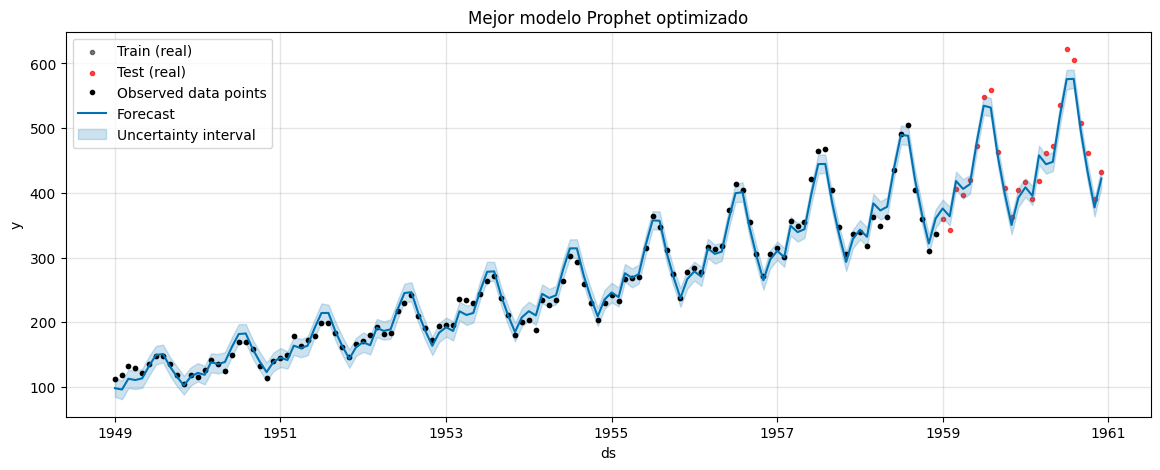

(19.675260099930252, 16.598503487854853, 387.1158599999074, 0.9305831893933617)

In [ ]:
# Mostrar gráfico del mejor modelo
graficar_mejor_modelo(study)